In [ ]:
# data (https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

In [1]:
import pandas as pd 
import seaborn as sns 

In [3]:
data = pd.read_csv("wdbc.data")
data.head()

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [7]:
print(data.describe().T)
print(data.isnull().sum)

          count          mean           std          min            25%  \
842302    568.0  3.042382e+07  1.251246e+08  8670.000000  869222.500000   
17.99     568.0  1.412049e+01  3.523416e+00     6.981000      11.697500   
10.38     568.0  1.930533e+01  4.288506e+00     9.710000      16.177500   
122.8     568.0  9.191475e+01  2.428585e+01    43.790000      75.135000   
1001      568.0  6.542798e+02  3.519238e+02   143.500000     420.175000   
0.1184    568.0  9.632148e-02  1.404601e-02     0.052630       0.086290   
0.2776    568.0  1.040360e-01  5.235523e-02     0.019380       0.064815   
0.3001    568.0  8.842731e-02  7.929422e-02     0.000000       0.029540   
0.1471    568.0  4.874629e-02  3.861717e-02     0.000000       0.020310   
0.2419    568.0  1.810549e-01  2.731942e-02     0.106000       0.161900   
0.07871   568.0  6.276960e-02  7.034862e-03     0.049960       0.057697   
1.095     568.0  4.039576e-01  2.760385e-01     0.111500       0.232375   
0.9053    568.0  1.217402

In [19]:
data.columns

Index(['842302', 'M', '17.99', '10.38', '122.8', '1001', '0.1184', '0.2776',
       '0.3001', '0.1471', '0.2419', '0.07871', '1.095', '0.9053', '8.589',
       '153.4', '0.006399', '0.04904', '0.05373', '0.01587', '0.03003',
       '0.006193', '25.38', '17.33', '184.6', '2019', '0.1622', '0.6656',
       '0.7119', '0.2654', '0.4601', '0.1189'],
      dtype='object')

In [30]:
data = data.rename(columns={data.columns[0]: "Label"})
print(data.dtypes)
print(data.columns)

Label         int64
M            object
17.99       float64
10.38       float64
122.8       float64
1001        float64
0.1184      float64
0.2776      float64
0.3001      float64
0.1471      float64
0.2419      float64
0.07871     float64
1.095       float64
0.9053      float64
8.589       float64
153.4       float64
0.006399    float64
0.04904     float64
0.05373     float64
0.01587     float64
0.03003     float64
0.006193    float64
25.38       float64
17.33       float64
184.6       float64
2019        float64
0.1622      float64
0.6656      float64
0.7119      float64
0.2654      float64
0.4601      float64
0.1189      float64
dtype: object
Index(['Label', 'M', '17.99', '10.38', '122.8', '1001', '0.1184', '0.2776',
       '0.3001', '0.1471', '0.2419', '0.07871', '1.095', '0.9053', '8.589',
       '153.4', '0.006399', '0.04904', '0.05373', '0.01587', '0.03003',
       '0.006193', '25.38', '17.33', '184.6', '2019', '0.1622', '0.6656',
       '0.7119', '0.2654', '0.4601', '0.1189'],


<AxesSubplot:xlabel='Label', ylabel='count'>

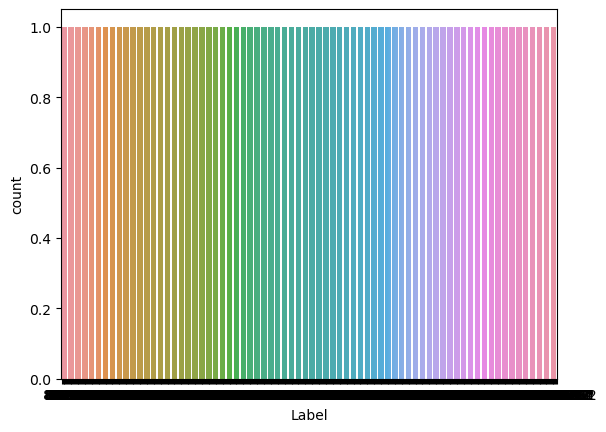

In [31]:
sns.countplot(x="Label", data=data)

In [34]:
# replace categorical values with numbers
data['Label'].value_counts()

842517     1
90250      1
901315     1
9013579    1
9013594    1
          ..
873885     1
873843     1
873701     1
873593     1
92751      1
Name: Label, Length: 568, dtype: int64

In [36]:
#Define the dependent variable that needs to be predicted (labels)
y = data["Label"].values

In [40]:
# Encoding categorical data 
from sklearn.preprocessing import LabelEncoder
labelencoder= LabelEncoder()
Y = labelencoder.fit_transform(y)
X = data.drop(labels = ["Label"], axis=1) 

In [53]:
X = data.drop(labels = ["Label", "ID"], axis=1) 

KeyError: "['Label', 'ID'] not found in axis"

In [41]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X)
X = scaler.transform(X)

ValueError: could not convert string to float: 'M'

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)


In [43]:
#RANDOM FOREST, to compare against xgboost
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 10, random_state = 42)

In [54]:
print(np.unique(y_train))

<IPython.core.display.Javascript object>

[  0   1   2   4   5   6   7   8   9  10  11  12  14  15  16  17  19  20
  21  22  23  24  26  27  29  30  31  32  34  36  37  38  40  42  43  44
  47  49  51  52  53  54  55  56  57  59  61  62  63  64  65  67  68  69
  70  71  72  73  74  75  76  77  79  80  81  82  83  84  85  86  87  88
  89  91  93  96 100 101 102 103 104 105 106 107 109 110 112 113 114 116
 117 118 119 120 123 124 125 126 127 128 129 130 131 133 134 135 136 138
 139 141 142 143 147 149 150 151 152 153 155 156 157 160 163 164 165 166
 167 168 170 172 173 174 176 177 179 180 182 183 184 185 186 187 188 191
 193 194 195 196 197 199 200 201 202 204 205 206 207 208 210 212 213 215
 216 217 218 220 221 222 223 224 225 226 228 229 230 233 234 237 238 239
 240 241 242 243 244 245 246 247 248 249 252 253 254 255 256 257 259 261
 262 263 264 267 268 270 271 272 273 274 275 276 277 280 281 282 283 284
 285 289 290 292 293 294 295 297 298 299 300 301 303 304 305 306 307 309
 310 311 312 313 314 315 316 317 318 319 320 321 32

In [55]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

In [57]:
# fit model to XGBOOST
import xgboost as xgb
model = xgb.XGBClassifier()

model.fit(X_train, y_train)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 

In [58]:
# Predicting the Test set results
y_pred = model.predict(X_test)

NotFittedError: need to call fit or load_model beforehand

In [59]:
#Evaluate the classifier on test data
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)


NameError: name 'y_pred' is not defined

In [60]:
print("Accuracy = ", (accuracy * 100.0), "%")

NameError: name 'accuracy' is not defined

In [61]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)

NameError: name 'y_pred' is not defined